# F-Test for Equal Variances (Two-Sample)

The **two-sample F-test** tests whether two populations have the same variance. The test statistic is the ratio of sample variances and follows an F-distribution under H₀.

| Property | Value |
|---|---|
| **H₀** | σ₁² = σ₂² |
| **H₁** | σ₁² ≠ σ₂² (two-tailed) |
| **Test statistic** | F = s₁² / s₂² (larger variance in numerator) |
| **Distribution** | F(n₁−1, n₂−1) under H₀ |
| **Assumption** | Both samples must be normally distributed |
| **Alternative** | Use Levene/Bartlett for non-normal data or k>2 groups |
| **CI for ratio** | (F/F_upper, F/F_lower) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

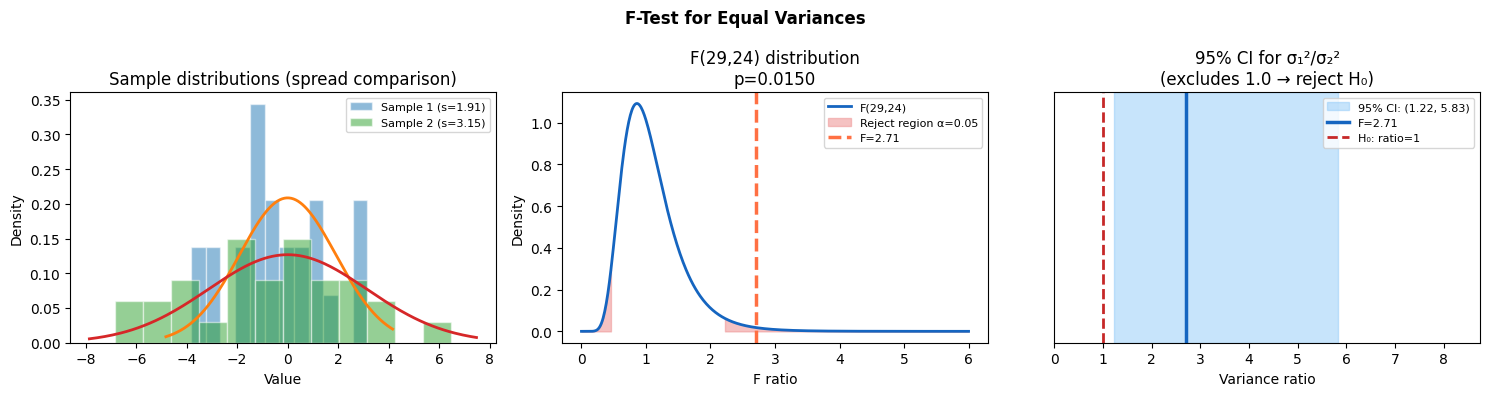

s1²=3.6600, s2²=9.9108, F=2.7079, p=0.0150
95% CI for σ²_larger/σ²_smaller: (1.221, 5.833)
Ratio of SDs: 1.646


In [2]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('F-Test for Equal Variances', fontsize=12, fontweight='bold')

n1, n2 = 25, 30
g1 = np.random.normal(0, 2.0, n1)   # σ=2
g2 = np.random.normal(0, 3.5, n2)   # σ=3.5

s1_sq = g1.var(ddof=1)
s2_sq = g2.var(ddof=1)
# Put larger variance in numerator
if s1_sq >= s2_sq:
    F_stat = s1_sq / s2_sq
    df1, df2 = n1-1, n2-1
else:
    F_stat = s2_sq / s1_sq
    df1, df2 = n2-1, n1-1
# Two-tailed p-value
p_val = 2 * min(stats.f.cdf(F_stat, df1, df2), stats.f.sf(F_stat, df1, df2))

# Panel 1: spread comparison
for data, label, color in [(g1, f'Sample 1 (s={g1.std(ddof=1):.2f})', '#1565C0'),
                            (g2, f'Sample 2 (s={g2.std(ddof=1):.2f})', '#C62828')]:
    axes[0].hist(data, bins=12, density=True, alpha=0.5, label=label,
                 edgecolor='white')
    x = np.linspace(data.min()-1, data.max()+1, 200)
    axes[0].plot(x, stats.norm(0, data.std(ddof=1)).pdf(x), lw=2)
axes[0].set_title('Sample distributions (spread comparison)')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Panel 2: F-distribution
F_range = np.linspace(0, 6, 500)
F_pdf = stats.f.pdf(F_range, df1, df2)
F_crit_hi = stats.f.ppf(0.975, df1, df2)
F_crit_lo = stats.f.ppf(0.025, df1, df2)
axes[1].plot(F_range, F_pdf, color='#1565C0', lw=2, label=f'F({df1},{df2})')
axes[1].fill_between(F_range, F_pdf, where=F_range >= F_crit_hi, color='#EF9A9A', alpha=0.6)
axes[1].fill_between(F_range, F_pdf, where=F_range <= F_crit_lo, color='#EF9A9A', alpha=0.6, label='Reject region α=0.05')
axes[1].axvline(F_stat, color='#FF7043', lw=2.5, ls='--', label=f'F={F_stat:.2f}')
axes[1].set_title(f'F({df1},{df2}) distribution\np={p_val:.4f}')
axes[1].set_xlabel('F ratio'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)

# Panel 3: CI for variance ratio
F_lo = F_stat / F_crit_hi
F_hi = F_stat / stats.f.ppf(0.025, df1, df2)
ratios = np.linspace(0.1, 8, 400)
axes[2].axvspan(F_lo, F_hi, color='#90CAF9', alpha=0.5, label=f'95% CI: ({F_lo:.2f}, {F_hi:.2f})')
axes[2].axvline(F_stat, color='#1565C0', lw=2.5, label=f'F={F_stat:.2f}')
axes[2].axvline(1.0, color='#C62828', lw=2, ls='--', label='H₀: ratio=1')
axes[2].set_xlim(0, max(F_hi*1.5, 3))
axes[2].set_title("95% CI for σ₁²/σ₂²\n(excludes 1.0 → reject H₀)")
axes[2].set_xlabel('Variance ratio'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f's1²={s1_sq:.4f}, s2²={s2_sq:.4f}, F={F_stat:.4f}, p={p_val:.4f}')
print(f'95% CI for σ²_larger/σ²_smaller: ({F_lo:.3f}, {F_hi:.3f})')
print(f'Ratio of SDs: {np.sqrt(F_stat):.3f}')

## Key Takeaways

| | |
|---|---|
| **F = s₁²/s₂²** | Put larger variance in numerator → always F ≥ 1 for two-tailed test |
| **Sensitive to normality** | F-test breaks down severely when data is non-normal |
| **CI excludes 1** | Reject H₀ when 95% CI for σ₁²/σ₂² does not include 1.0 |
| **k > 2 groups** | Use Bartlett (normal) or Levene (robust) for multiple groups |
| **Practical significance** | Even non-significant, check if SD ratio > 2 before pooled ANOVA |
| **Reciprocal** | F(df1,df2) and 1/F(df2,df1) are equivalent |